# Assignment 3: LLMs and Machine Learning

---

## Statement of use of AI

I completed this assignment with the assistance of Claude (Anthropic) as a learning aid. Claude was used to provide guidance, ask leading questions, explain concepts, and helping debug errors. Claude did not generate ready-made code . All code was written by me or copy pasted from the lecture materials, and all analytical decisions (model selection, hyperparameter choices, interpretation of results) were made by me, following the examples in the lecture materials. Claude helped explain concepts such as non-determinism in LLMs, encoding methods, scaling, and machine learning metrics.

In [179]:
# Importing needed libraries
!pip install openai
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Tasks

### Task 0: Setting up Ollama (1p)

a) Set up Ollama and connect to it using either openAI's API or Ollama's own API. 

b) Load the 270m parameter version of the [gemma3](https://ollama.com/library/gemma3) model and test it with any prompt.

c) Load the 4b parameter version of the [gemma3](https://ollama.com/library/gemma3) and test it with any prompt. If running the 4b version is too slow, you can use the 1b version instead.

In [48]:
from openai import OpenAI

# --- Configuration ---

# Define the default model 
MODEL = "gemma3:270m"

# Connect to the local Ollama server
ollama_client = OpenAI(
    base_url="http://localhost:11434/v1/",
    api_key="ollama") 

#Define the function with a local variable model and global variable MODEL
def ask_llm(prompt, model=MODEL):
    """Send a prompt to the local LLM and return the response text."""
    #print(f"Using model: {model}")
    response = ollama_client.chat.completions.create(
        model=model,
        messages=[
            {"role": "user", "content": prompt}
        ]
    )
    return response.choices[0].message.content

#Call the function
print(ask_llm("What is the meaning of life?"))
#print(" ")
#print(ask_llm("What is the answer to the Ultimate Question of Life, the Universe, and Everything?", model="gemma3:4b"))


The meaning of life is a question that has been pondered by humanity for centuries. There is no single, universally accepted answer, and the idea of a definitive meaning is often seen as a source of existential angst.



### Task 1: Text classification with Ollama (2p)

The `data/emails.csv` file contains 12 email headlines, with 4 spam emails, 4 legitimate work emails and 4 vague emails that are hard to classify based on the title alone. Use this dataset for all subtasks in this task.

In [21]:
emails = pd.read_csv("data/emails.csv", sep='\t')
emails

#importing the dataset as pandas dataframe

emails = pd.read_csv("data/emails.csv", sep='\t')
#emails

,headline
0,URGENT: Your account will be suspended within ...
1,Congratulations! You have won a 1000€ gift car...
2,Hot singles in your area are waiting to meet y...
3,Re: Inheritance transfer of 4.5M USD pending y...
4,Meeting agenda for Thursday's project review
5,"Q3 budget report attached, please review by Fr..."
6,Reminder: Annual performance review scheduled ...
7,"Updated draft of the manuscript, comments welcome"
8,Quick question about last week
9,Following up


### Task 1: Text classification with Ollama (2p)

a) Make a function for classifying emails (based on the headlines) as spam, work or unknown. The function should return only the classification and nothing else. (0.5p)



In [177]:
def classify_email(text, model=MODEL):
    """Classify the email based on the email headlines as spam, work or unknown."""
    prompt = f"""Classify the type of the following emails based on the headline.
Respond with exactly one of these words and do not use any other words: Spam, Work, Unknown.

Email: {text}"""
    result = ask_llm(prompt, model)
    return result.strip()

# Test on the first headline
print(classify_email(emails.loc[0, "headline"]))

Suspended


### Task 1: Text classification with Ollama (2p)

b) Use the smaller gemma3 (270m) to classify the emails using the function created in part a. (0.5p)



In [52]:
# Apply classify_email to all emails with gemma3 (270m)
emails["classification"] = emails["headline"].apply(classify_email)

emails[["headline", "classification"]]


,headline,classification
0,URGENT: Your account will be suspended within ...,Suspended
1,Congratulations! You have won a 1000€ gift car...,Congratulations!
2,Hot singles in your area are waiting to meet y...,Email
3,Re: Inheritance transfer of 4.5M USD pending y...,Tax
4,Meeting agenda for Thursday's project review,Slam
5,"Q3 budget report attached, please review by Fr...",Email
6,Reminder: Annual performance review scheduled ...,Reminder
7,"Updated draft of the manuscript, comments welcome",Comment
8,Quick question about last week,Polite
9,Following up,Subject: Following Up on [Project Name]\n\nDea...


### Task 1: Text classification with Ollama (2p)

c) Use larger gemma3 (4b) to classify the emails using the function created in part a). In separate markdown cell, write a brief comment comparing the results of parts b) and c). (0.5p)


In [55]:
# Apply classify_email to all emails with gemma3 (4b) 
emails["classification"] = emails["headline"].apply(lambda x: classify_email(x, model="gemma3:4b"))

emails[["headline", "classification"]]

,headline,classification
0,URGENT: Your account will be suspended within ...,Spam
1,Congratulations! You have won a 1000€ gift car...,Spam
2,Hot singles in your area are waiting to meet y...,Spam
3,Re: Inheritance transfer of 4.5M USD pending y...,Spam
4,Meeting agenda for Thursday's project review,Work
5,"Q3 budget report attached, please review by Fr...",Work
6,Reminder: Annual performance review scheduled ...,Work
7,"Updated draft of the manuscript, comments welcome",Work
8,Quick question about last week,Unknown
9,Following up,Unknown


This was a very interesting exercise and experience with LLMs.

When I ran gemma3 (270m) for the first time, it gave me a very good result and I was very impressed by the model. Then I tweaked my code and reran it several times, and the output got worse and worse. The final output I got makes no sense as can be seen in the current output. This really highlights the fact the LLMs are not deterministic. For the gemma3 (4b), at least this first run with the ouput above gave very good results. However, I will not draw any conclusions about the differences between these two models until I run both of them multiple (3) times, because my first attempt with the smaller gemma3 (270m) was also succesful.


### Task 1: Text classification with Ollama (2p)

d) Write a script that repeats b) and c) 3 times, storing the results for both models separately. For both models, put the results as columns into a new DataFrame that also contains the headlines so that it is easy to compare how the output varied across runs for both models. Comment if there were differences and explain why this happened. (0.5p)

In [63]:
#create a disctionary with two new dataframes to store the results
results = {
    "gemma3:270m": emails[["headline"]].copy(),
    "gemma3:4b": emails[["headline"]].copy()
}

#Create a nested for loop which first loops over the models and then three times runs the classify_email function
for model in results:
    for r in range(3):
        results[model][f"run_{r+1}"] = emails["headline"].apply(lambda x: classify_email(x, model))
    

display(results["gemma3:270m"])
display(results["gemma3:4b"])  


,headline,run_1,run_2,run_3
0,URGENT: Your account will be suspended within ...,Suspended,Suspension,Suspended
1,Congratulations! You have won a 1000€ gift car...,Thank you!,Tax,Enjoy
2,Hot singles in your area are waiting to meet y...,spam,Email,**Work**
3,Re: Inheritance transfer of 4.5M USD pending y...,Pending,Tax,Prime
4,Meeting agenda for Thursday's project review,Testimonial,Send,Smart
5,"Q3 budget report attached, please review by Fr...",Wasted,spam,Send
6,Reminder: Annual performance review scheduled ...,**Review**,**Work**,
7,"Updated draft of the manuscript, comments welcome",Email,An Email,
8,Quick question about last week,Question,Question,Email
9,Following up,Spam,Follow Up,Spam


,headline,run_1,run_2,run_3
0,URGENT: Your account will be suspended within ...,Spam,Spam,Spam
1,Congratulations! You have won a 1000€ gift car...,Spam,Spam,Spam
2,Hot singles in your area are waiting to meet y...,Spam,Spam,Spam
3,Re: Inheritance transfer of 4.5M USD pending y...,Spam,Spam,Spam
4,Meeting agenda for Thursday's project review,Work,Work,Work
5,"Q3 budget report attached, please review by Fr...",Work,Work,Work
6,Reminder: Annual performance review scheduled ...,Work,Work,Work
7,"Updated draft of the manuscript, comments welcome",Work,Work,Work
8,Quick question about last week,Unknown,Unknown,Unknown
9,Following up,Unknown,Unknown,Unknown


There is major difference between the two models. The larger gemma3:4b does a much better job in classifying the emails, and it does it consistently. The smaller model is actually quite unreliable. The model size and capacity to follow instructions is substantially different and clearly affects the performance.

### Task 2: Sentiment analysis with Ollama (2p)

The `data/news.csv` file contains 10 fictional financial news headlines. Use it for all subtasks in this task.

In [72]:
#importing the dataset as pandas dataframe
news = pd.read_csv("data/news.csv", sep='\t')
news.head()

['Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28%',
 'Helvora Pharmaceuticals misses earnings forecast amid weak generics demand',
 'Aurelis Bank reports steady quarterly profit, in line with analyst expectations',
 'Veridyne Logistics to acquire rival Trantec in 4.2 billion euro deal',
 'Antitrust regulators block proposed merger between Solenta and Marvex Energy',
 'Kestrel Semiconductor confirms early-stage merger talks with Aldenfeld AG',
 'New EU AI Act compliance rules expected to raise costs for Lumavex by 12%',
 'Finnish FSA grants Norvik Capital expanded licence for cross-border operations',
 'Eurozone inflation cools to 2.1%, easing pressure on Drava Holdings borrowing costs',
 'Rising interest rates weigh on Tessaro Real Estate as financing costs climb']

### Task 2: Sentiment analysis with Ollama (2p)

a) Make a function for classifying the texts in the provided dataset based on the topic (earnings, mergers, regulation, macroeconomics) and for determining the sentiment of the news (positive, negative, neutral). The function should return the class and sentiment in JSON format. (1p)

In [110]:
def classify_news(text, model=MODEL):
    """Classify the news based on the news headlines based on the topic (earnings, mergers, regulation, macroeconomics) and for determining the sentiment of the news (positive, negative, neutral)."""
    prompt = f"""Classify the topic and determine the sentiment of the following news based on the headline.
When classifying the topic, respond with exactly one of these words: earnings, mergers, regulation, macroeconomics. Do not use any other words
When determining the sentiment, respond with exactly one of these words: positive, negative, neutral. Do not use any other words
Respond only in JSON format like this {{"topic": "...", "sentiment": "..."}}. 

News: {text}"""
    result = ask_llm(prompt, model)
    #print(repr(result))
    result=result.replace("```json", "").replace("```", "").replace("\n", "")
    #print(repr(result))
    return result.strip()

# Test on the first headline
print(classify_news(news.loc[0, "headline"]))

{"topic": "earnings", "sentiment": "positive"}


### Task 2: Sentiment analysis with Ollama (2p)
b) Use gemma3 (4b) to classify and provide the sentiment for each row of the provided dataset, inserting them into a new DataFrame that contains both the original headlines as well as topic and sentiment. (0.5p)

In [112]:
# Apply classify_news to all news headlines with gemma3 (4b) 
import json

news_results= news[["headline"]].copy() #creates a new dataframe where the results are eventually stored. 

parsed= news["headline"].apply(lambda x: json.loads(classify_news(x, model="gemma3:4b"))) #applies classify_news to the headlines with model gemma3:4b and 

pd.json_normalize(parsed) #

news_results= pd.concat([news_results, pd.json_normalize(parsed)], axis=1)
display(news_results)


,headline,topic,sentiment
0,Nordion Industries beats Q1 earnings estimates...,earnings,positive
1,Helvora Pharmaceuticals misses earnings foreca...,earnings,negative
2,"Aurelis Bank reports steady quarterly profit, ...",earnings,positive
3,Veridyne Logistics to acquire rival Trantec in...,mergers,positive
4,Antitrust regulators block proposed merger bet...,regulation,negative
5,Kestrel Semiconductor confirms early-stage mer...,mergers,neutral
6,New EU AI Act compliance rules expected to rai...,regulation,negative
7,Finnish FSA grants Norvik Capital expanded lic...,regulation,positive
8,"Eurozone inflation cools to 2.1%, easing press...",macroeconomics,positive
9,Rising interest rates weigh on Tessaro Real Es...,macroeconomics,negative


### Task 2: Sentiment analysis with Ollama (2p)

c) Give the same data and prompt to a browser based LLM (e.g. ChatGPT, LeChat, Claude or Gemini) and ask it to provide the topic and sentiment, giving it the same options. Paste the results into a markdown cell. Compare the results of b) and c), which one is more accurate and why? (0.5p)

I used ChatGPT with the following prompt:  
"Classify the topic and determine the sentiment of the news based on the headline, provided in the csv file. When classifying the topic, respond with exactly one of these words: earnings, mergers, regulation, macroeconomics. Do not use any other words When determining the sentiment, respond with exactly one of these words: positive, negative, neutral. Do not use any other words."

The result was:

| headline | topic | sentiment |
|---|---|---|
| Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28% | earnings | positive |
| Helvora Pharmaceuticals misses earnings forecast amid weak generics demand | earnings | negative |
| Aurelis Bank reports steady quarterly profit, in line with analyst expectations | earnings | neutral |
| Veridyne Logistics to acquire rival Trantec in 4.2 billion euro deal | mergers | positive |
| Antitrust regulators block proposed merger between Solenta and Marvex Energy | mergers | negative |
| Kestrel Semiconductor confirms early-stage merger talks with Aldenfeld AG | mergers | neutral |
| New EU AI Act compliance rules expected to raise costs for Lumavex by 12% | regulation | negative |
| Finnish FSA grants Norvik Capital expanded licence for cross-border operations | regulation | positive |
| Eurozone inflation cools to 2.1%, easing pressure on Drava Holdings borrowing costs | macroeconomics | positive |
| Rising interest rates weigh on Tessaro Real Estate as financing costs climb | macroeconomics | negative |

During this run, the results were exactly the same except for two differences.
1) Ollama classified "Antitrust regulators block proposed merger between Solenta and Marvex Energy" topic as regulation, whereas ChatGPT categorised it as mergers. I asked ChatGPT why it differs, and it responded: _"For row 4, both labels are defensible, but I would now lean regulation because the main event is antitrust regulators blocking the deal, rather than the merger activity itself."_ So after I told it that another LLM classified it as regulation, it actually changed its mind.
2) Ollama determined the sentiment of "Aurelis Bank reports steady quarterly profit, in line with analyst expectations" as positive, whereas ChatGPT determined it as neutral. Again, I asked ChatGPT why and it responded: _"For row 2, I classified it as neutral because “steady” and “in line with analyst expectations”_ suggest no surprise, even though profit itself is generally positive."

So I would conclude that both models performed well, but perhaps Ollama was a bit better this time because I, and eventually ChatGPT agreed that the first difference is regulation. For the second, I am unable to decide which one is correct. 


### Task 3: Supervised machine learning (5p)

For this task, use a subset of the [Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing) dataset, by downloading and importing the `bank-additional.csv` from the UCI repository. You can find a description of the dataset behind the link.

The goal is to predict whether a prospective customer will subscribe to a term deposit (variable y).

a) Import the dataset and conduct exploratory data analysis on it. (1p)

b) Preprocess the data using the appropriate methods as described in the course materials. (1p)

In [139]:
bank = pd.read_csv("data/bank-additional.csv", sep=";")
bank.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


Basic info about the DF
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf

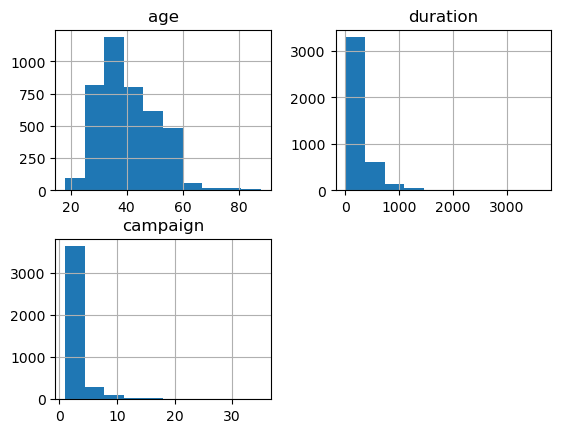

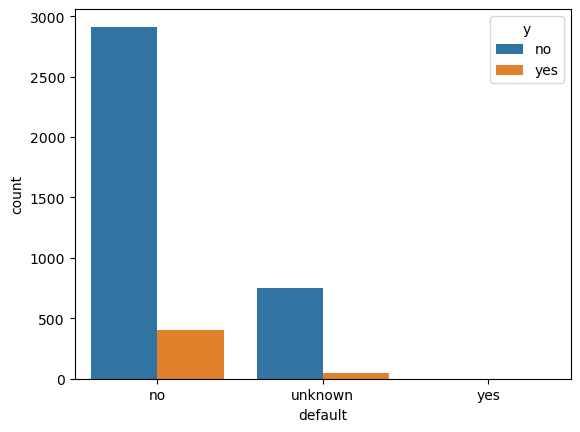

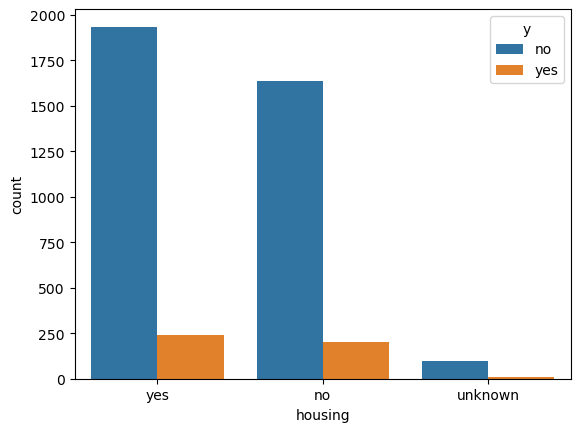

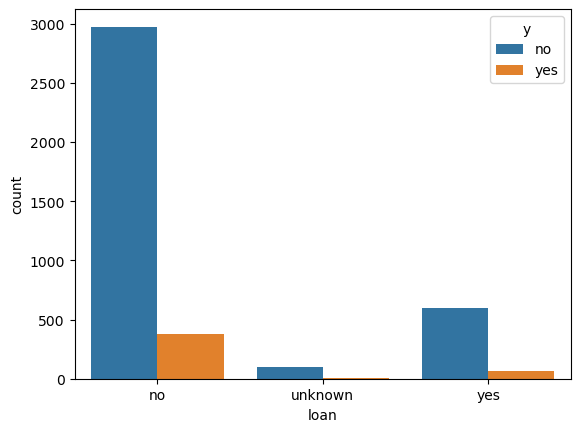

In [130]:
#EDA
print("Basic info about the DF")
bank.info()
print()
print("Shape of the dataframe")
print(bank.shape)
print()
print("Basic statistics for each variable")
print(bank.describe())
print()
print("Distribution of the target variable")
print(bank['y'].value_counts())
print()
print("Check for missing values")
print(bank.isnull().sum())


bank[['age', 'duration', 'campaign']].hist()

sns.countplot(data=bank, x='marital', hue='y') #marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
plt.show()
sns.countplot(data=bank, x='default', hue='y') #has credit in default?
plt.show()
sns.countplot(data=bank, x='housing', hue='y') #average yearly balance
plt.show()
sns.countplot(data=bank, x='loan', hue='y') #has housing loan?
plt.show()

### Task 3: Supervised machine learning (5p)
b) Preprocess the data using the appropriate methods as described in the course materials. (1p)

From the course material: 

Some examples of ways to clean and preprocess data: <br>
• Convert fields with text into numeric form _will do one-hot and label encoding_  <br>
• Remove rows with missing / faulty data   _No rows with missing values_ <br> 
• Fix rows with faulty datapoints  <br>
• Drop unnecessary variables (columns) _From the UCI description: Thus, duration should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model._<br>
• Scaling or normalizing data <br>
• Creating new variables <br>
• Renaming variables (remove capitalization, spaces) <br>


In [140]:
# b) One-hot encoding for job, marital, default, housing, loan, contact, month, day_of_week, poutcome
bank = pd.get_dummies(bank, columns=["job", "marital", "default", "housing", "loan", "contact", "month","day_of_week","poutcome" , "education"], drop_first=True, dtype=float)
bank.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,day_of_week_wed,poutcome_nonexistent,poutcome_success,education_basic.6y,education_basic.9y,education_high.school,education_illiterate,education_professional.course,education_university.degree,education_unknown
0,30,487,2,999,0,-1.8,92.893,-46.2,1.313,5099.1,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,39,346,4,999,0,1.1,93.994,-36.4,4.855,5191.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,25,227,1,999,0,1.4,94.465,-41.8,4.962,5228.1,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,38,17,3,999,0,1.4,94.465,-41.8,4.959,5228.1,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,47,58,1,999,0,-0.1,93.200,-42.0,4.191,5195.8,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [148]:
# b) Label encoding for y
from sklearn.preprocessing import LabelEncoder
le_y=LabelEncoder()

bank["y"] = le_y.fit_transform(bank["y"])

bank["y"].value_counts()
print(bank.columns)

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_married', 'marital_single', 'marital_unknown',
       'default_unknown', 'default_yes', 'housing_unknown', 'housing_yes',
       'loan_unknown', 'loan_yes', 'contact_telephone', 'month_aug',
       'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may',
       'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon',
       'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed',
       'poutcome_nonexistent', 'poutcome_success', 'education_basic.6y',
       'education_basic.9y', 'education_high.school', 'education_illiterate',
       'education_professional.course', 'education_university.degree',
       

In [152]:
#Drop duration

bank=bank.drop(["duration"], axis=1)
print(bank.columns)

Index(['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_married', 'marital_single', 'marital_unknown',
       'default_unknown', 'default_yes', 'housing_unknown', 'housing_yes',
       'loan_unknown', 'loan_yes', 'contact_telephone', 'month_aug',
       'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may',
       'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon',
       'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed',
       'poutcome_nonexistent', 'poutcome_success', 'education_basic.6y',
       'education_basic.9y', 'education_high.school', 'education_illiterate',
       'education_professional.course', 'education_university.degree',
       'education_u

In [153]:
# b) Standardization for age, campaign, pdays, previous, emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed.
from sklearn.preprocessing import StandardScaler

scaler_standard = StandardScaler()
bank[["age", "campaign", "pdays", "previous", "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]] = scaler_standard.fit_transform(bank[["age", "campaign", "pdays", "previous", "emp.var.rate", 
                                                                                                                                                                                       "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]])
bank.head()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,...,day_of_week_wed,poutcome_nonexistent,poutcome_success,education_basic.6y,education_basic.9y,education_high.school,education_illiterate,education_professional.course,education_university.degree,education_unknown
0,-0.980752,-0.209228,0.201031,-0.351356,-1.206054,-1.185448,-1.240939,-1.331707,-0.914779,0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,-0.107991,0.569634,0.201031,-0.351356,0.649441,0.715193,0.892269,0.711698,0.332862,0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,-1.465619,-0.598660,0.201031,-0.351356,0.841389,1.528273,-0.283172,0.773427,0.836535,0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,-0.204965,0.180203,0.201031,-0.351356,0.841389,1.528273,-0.283172,0.771697,0.836535,0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.667795,-0.598660,0.201031,-0.351356,-0.118350,-0.655478,-0.326707,0.328632,0.398028,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### Task 3: Supervised machine learning (5p)

The goal is to predict whether a prospective customer will subscribe to a term deposit (variable y).

c) Determine whether this is a classification or regression task. Choose three different machine learning algorithms from scikit-learn and explain briefly why you chose them. For each of the selected algorithsm, train a model and iteratively adjust the hyperparameters until you no longer manage to improve the performance. (1p)

This is a classification task, because we are trying to predict a category (yes, no) and not a continuous number which would turn this into a regression task.

I will use 
- Random Forest, because it is suitable for these kinds of tasks. Random forests _"is an ensemble learning method for classification [...] that works by creating a multitude of decision trees during training. For classification tasks, the output of the random forest is the class selected by most trees."_(wikipedia)
- KNN (K-Nearest Neighbours) is meant to be a simple algorithm, which is used for classification and it predicts a data point's label based on the majority vote of its \(k\) closest neighbors.
- Support Vector Machine (SVM) is a well-studied algorithm, which is suitable for binary (yes/no) classification problems, such as the one in the task. 


In [154]:
# c) For each of the selected algorithsm, train a model and iteratively adjust the hyperparameters until you no longer manage to improve the performance.

#Train-test split (80/20)
from sklearn.model_selection import train_test_split

# Encode target variable
y = bank["y"]
X = bank.drop(columns=["y"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print("\nClass balance (train):")
print(y_train.value_counts())
print("\nClass balance (test):")
print(y_test.value_counts())

Train set size: 3295
Test set size: 824

Class balance (train):
y
0    2936
1     359
Name: count, dtype: int64

Class balance (test):
y
0    732
1     92
Name: count, dtype: int64


In [155]:
# c) Train-validation-test split (60/20/20)
# First split: 80/20 into train+val and test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Second split: 75/25 of the 80% into train and validation (0.75 * 0.8 = 0.6, 0.25 * 0.8 = 0.2)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print("Train set size:", X_train.shape[0])
print("Validation set size:", X_val.shape[0])
print("Test set size:", X_test.shape[0])
print("\nClass balance (train):")
print(y_train.value_counts())

Train set size: 2471
Validation set size: 824
Test set size: 824

Class balance (train):
y
0    2206
1     265
Name: count, dtype: int64


In [156]:
# c) Train an SVM model and predict on validation set
from sklearn.svm import SVC

svm_model = SVC(random_state=42, class_weight="balanced")
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_val)

In [157]:
# b) Train a Random Forest model and predict on validation set
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)

In [158]:
# b) Train a K-nearest neighbor model and predict on validation set
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_val)

In [159]:
# c) Accuracy, Precision, Recall, F1-score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

for name, y_pred in [("SVM", y_pred_svm), ("Random Forest", y_pred_rf), ("KNN", y_pred_knn)]:
    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_val, y_pred):.4f}")
    print(f"Precision: {precision_score(y_val, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_val, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_val, y_pred):.4f}")
    print()

--- SVM ---
Accuracy:  0.8410
Precision: 0.3688
Recall:    0.5532
F1-score:  0.4426

--- Random Forest ---
Accuracy:  0.8859
Precision: 0.5000
Recall:    0.2021
F1-score:  0.2879

--- KNN ---
Accuracy:  0.8896
Precision: 0.5263
Recall:    0.3191
F1-score:  0.3974



### Interpertation

- Accuracy is high for all three (~84-89%). However, the distribution of the yes and no answers was highly skewed towards no answers, so a model that would always predict no would get a 89% accuracy. Therefore, this is not the best metric to decide which model to use. 
- KNN has the highest Precision, SVM the lowest. This tells the share of customers that the model predicted would subscribe to the actual number of customers who subscribed. 
- SVM has the highest Recall (0.55). This means it catches more actual "yes" cases, but at the cost of more false positives (lower precision). Random Forest has the worst Recall (0.20) meaing it misses most actual subscribers, and KNN is in between. This is an important metric because the bank would not want to miss yes cases so customers who would have subscribed. So Since SVM performs the best in this, it might be the best model to choose. 

In [171]:
# c) GridSearch for SVM hyperparameters
from sklearn.model_selection import GridSearchCV
param_grid_svm = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.01, 0.1],
    "kernel": ["rbf"]
}
grid_svm = GridSearchCV(SVC(random_state=42, class_weight="balanced"), param_grid_svm, cv=5, scoring="recall", n_jobs=-1)
grid_svm.fit(X_train, y_train)
print("Best SVM parameters:", grid_svm.best_params_)
print("Best SVM Recall (CV):", f"{grid_svm.best_score_:.4f}")
# Evaluate on validation set
y_pred_svm_tuned = grid_svm.best_estimator_.predict(X_val)
print("SVM Validation Recall:", f"{recall_score(y_val, y_pred_svm_tuned):.4f}")

Best SVM parameters: {'C': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}
Best SVM Recall (CV): 0.7170
SVM Validation Recall: 0.6702


In [172]:
# b) GridSearch for Random Forest hyperparameters
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, None],
    "bootstrap": [True, False]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring="recall", n_jobs=-1)
#n_jobs=-1 tells scikit-learn to use all available CPU cores in parallel to speed up the search. -1 means "use all cores". 
grid_rf.fit(X_train, y_train)

print("Best RF parameters:", grid_rf.best_params_)
print("Best RF Recall (CV):", f"{grid_rf.best_score_:.4f}")

# Evaluate on validation set
y_pred_rf_tuned = grid_rf.best_estimator_.predict(X_val)
print("RF Validation Recall:", f"{recall_score(y_val, y_pred_rf_tuned):.4f}")

Best RF parameters: {'bootstrap': False, 'max_depth': None, 'n_estimators': 100}
Best RF Recall (CV): 0.2642
RF Validation Recall: 0.2128


In [173]:
# b) GridSearch for KNN hyperparameters
param_grid_knn = {
    "n_neighbors": [1,2,3,4,5,6,10]
}

grid_knn = GridSearchCV(KNeighborsClassifier(n_neighbors=3), param_grid_knn, cv=5, scoring="recall", n_jobs=-1)
grid_knn.fit(X_train, y_train)

print("Best KNN parameters:", grid_knn.best_params_)
print("Best KNN Recall (CV):", f"{grid_knn.best_score_:.4f}")

# Evaluate on validation set
y_pred_knn_tuned = grid_knn.best_estimator_.predict(X_val)
print("KNN Validation Recall:", f"{recall_score(y_val, y_pred_knn_tuned):.4f}")

Best KNN parameters: {'n_neighbors': 1}
Best KNN Recall (CV): 0.2830
KNN Validation Recall: 0.2128


### Task 3: Supervised machine learning (5p)
d) Compare using train, validation and test set split versus using cross-validation. Which one performs better? (1p)

Best SVM Recall (CV): 0.7170
Best RF Recall (CV): 0.2642
Best KNN Recall (CV): 0.2830

SVM Validation Recall: 0.6702
RF Validation Recall: 0.2128
KNN Validation Recall: 0.212

Cross-validation gives consistelntly higher Recall values than the train, validation and test set. 

### Task 3: Supervised machine learning (5p)

e) Report and evaluate the performance of the models using several of the metrics provided in the course, and explain which model is the best for the task and why. (1p)

In [174]:
# e) Final SVM evaluation on test set
y_pred_svm_final = grid_svm.best_estimator_.predict(X_test)

print("--- Final SVM (Test Set) ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_svm_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm_final):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_svm_final):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_svm_final):.4f}")

--- Final SVM (Test Set) ---
Accuracy:  0.7233
Precision: 0.2424
Recall:    0.6957
F1-score:  0.3596


In [175]:
# e) Final Random Forest evaluation on test set
y_pred_rf_final = grid_rf.best_estimator_.predict(X_test)

print("--- Final Random Forest (Test Set) ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_final):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf_final):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_rf_final):.4f}")

--- Final Random Forest (Test Set) ---
Accuracy:  0.8847
Precision: 0.4634
Recall:    0.2065
F1-score:  0.2857


In [176]:
# e) Final KNN evaluation on test set
y_pred_knn_final = grid_knn.best_estimator_.predict(X_test)

print("--- K-nearest neighbor (Test Set) ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_knn_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn_final):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_knn_final):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_knn_final):.4f}")

--- K-nearest neighbor (Test Set) ---
Accuracy:  0.8398
Precision: 0.2872
Recall:    0.2935
F1-score:  0.2903


SVM is clearly the best with Recall=0.70 — it correctly identifies 70% of actual subscribers, which is what matters most for the bank's marketing campaign. SVM catches more actual "yes" cases. Recall is the most important metric because the bank would not want to miss yes cases so customers who would have subscribed. 